<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Clase03_Note2_de_3_Redes_Convolucionales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Imágenes con Redes Neuronales Convolucionales (CNN)

Este notebook demuestra cómo construir, entrenar y evaluar una Red Neuronal Convolucional (CNN) para un problema de clasificación de imágenes binario: distinguir entre gatos y perros. Las CNN son el estándar de oro para tareas de visión por computadora debido a su capacidad para capturar jerarquías de características espaciales en las imágenes.

## ¿Qué es una Red Neuronal Convolucional?
Una CNN es un tipo especializado de red neuronal que utiliza capas particulares para procesar datos con una topología de cuadrícula, como una imagen.

Los componentes clave son:
1.  **Capa Convolucional (`Conv2D`)**: Aplica un conjunto de filtros (o *kernels*) a la imagen. Cada filtro está diseñado para detectar una característica específica, como bordes, texturas o formas. Al deslizar el filtro sobre la imagen, se crea un "mapa de características" que resalta dónde aparecen esas características.
2.  **Capa de Agrupación (`MaxPooling2D`)**: Reduce la dimensionalidad de los mapas de características. Toma una ventana (generalmente 2x2) y extrae el valor máximo, conservando la característica más prominente mientras reduce el tamaño computacional y proporciona invarianza a pequeñas traslaciones.
3.  **Capa de Aplanamiento (`Flatten`)**: Convierte la matriz 2D de características en un vector 1D para poder conectarla a una red neuronal densa tradicional.
4.  **Capas Densas (`Dense`)**: Las capas completamente conectadas que realizan la clasificación final basándose en las características extraídas por las capas convolucionales.

El flujo de trabajo que seguiremos es:
- **Configuración**: Preparar el entorno e instalar las librerías.
- **Preparación de Datos**: Descargar, extraer y cargar las imágenes usando generadores.
- **Construcción del Modelo**: Definir la arquitectura de la CNN.
- **Entrenamiento**: Entrenar el modelo con los datos de entrenamiento.
- **Evaluación**: Medir el rendimiento del modelo en datos no vistos.
- **Análisis de Predicciones**: Visualizar predicciones para entender el comportamiento del modelo.

## 1. Configuración del Entorno

Primero, instalamos las versiones correctas de las librerías y las importamos. También montaremos Google Drive para almacenar nuestros datos y el modelo entrenado de forma persistente.

In [ ]:
# Esta celda asegura que la versión de TensorFlow sea compatible con las operaciones de Keras utilizadas.
%pip install tensorflow==2.15.0 -q

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
import os
import requests
import zipfile
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

# Limpiar cualquier sesión de Keras previa para evitar conflictos
K.clear_session()

# Montar Google Drive
drive.mount("/content/drive")

# Definir la carpeta de trabajo
contentFolder = "/content/drive/MyDrive/Austral - Data Mining"
if not os.path.exists(contentFolder):
  os.makedirs(contentFolder)

# Crear el directorio para los datos de imágenes
image_dir = os.path.join(contentFolder, "animales")
if not os.path.exists(image_dir):
  os.makedirs(image_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Preparación de Datos

Descargamos los conjuntos de datos (entrenamiento, validación y prueba) y los extraemos en nuestra carpeta de trabajo.

In [ ]:
def download_file(url, save_path):
    """Descarga un archivo desde una URL a una ruta específica."""
    if not os.path.exists(save_path):
        print(f"Descargando {save_path}...")
        r = requests.get(url, stream=True)
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    else:
        print(f"{save_path} ya existe. Saltando descarga.")

def extract_zip(zip_path, extract_path):
    """Extrae un archivo zip a un directorio específico."""
    print(f"Extrayendo {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    os.remove(zip_path) # Eliminar el archivo zip después de la extracción
    print("Extracción completa.")

# URLs de los datasets
urls = {
    "train.zip": "https://drive.usercontent.google.com/download?id=1t1qqX3yjvKaLSHP62Ovp6l2RIYYLprdi&export=download&confirm=t",
    "test.zip": "https://drive.usercontent.google.com/download?id=1VXEOECTyFXRkirsSBF-siXF_h3XBUWQ_&export=download&confirm=t",
    "validation.zip": "https://drive.usercontent.google.com/download?id=1PVJ_8OIEiDftfdyaUqVkoQhDXBrEPEhr&export=download&confirm=t"
}

# Descargar y extraer los archivos
for filename, url in urls.items():
    zip_path = os.path.join(contentFolder, filename)
    download_file(url, zip_path)
    # Solo extraer si el directorio correspondiente no existe
    dir_name = filename.split('.')[0]
    if not os.path.exists(os.path.join(image_dir, dir_name)):
        extract_zip(zip_path, image_dir)
    elif os.path.exists(zip_path):
        print(f"El directorio {dir_name} ya existe. Eliminando {zip_path}.")
        os.remove(zip_path)


Descargando /content/drive/MyDrive/Austral - Data Mining/train.zip...
El directorio train ya existe. Eliminando /content/drive/MyDrive/Austral - Data Mining/train.zip.
Descargando /content/drive/MyDrive/Austral - Data Mining/test.zip...
El directorio test ya existe. Eliminando /content/drive/MyDrive/Austral - Data Mining/test.zip.
Descargando /content/drive/MyDrive/Austral - Data Mining/validation.zip...
El directorio validation ya existe. Eliminando /content/drive/MyDrive/Austral - Data Mining/validation.zip.


### Generadores de Imágenes y Aumento de Datos

Para manejar eficientemente grandes conjuntos de datos de imágenes, utilizamos `ImageDataGenerator` de Keras. Este objeto carga las imágenes en lotes (*batches*) directamente desde el directorio, evitando cargar todo en la memoria RAM.

También aplicaremos **Aumento de Datos (*Data Augmentation*)**. Esta es una técnica crucial para evitar el sobreajuste y mejorar la capacidad de generalización del modelo. Consiste en crear versiones modificadas de las imágenes de entrenamiento en tiempo real, aplicando transformaciones aleatorias como:

- `rescale=1./255`: Normaliza los valores de los píxeles de [0, 255] a [0, 1].
- `shear_range`: Aplica un corte o cizallamiento.
- `zoom_range`: Hace un zoom aleatorio en la imagen.
- `horizontal_flip`: Invierte la imagen horizontalmente.

Esto enseña al modelo a ser robusto a variaciones de posición, escala y orientación.

In [ ]:
# Definir rutas a los directorios de datos
train_dir = os.path.join(image_dir, "train")
validation_dir = os.path.join(image_dir, "validation")
test_dir = os.path.join(image_dir, "test")

# Parámetros para los generadores y el modelo
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

# Generador para los datos de entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

# Generador para los datos de validación y prueba (solo reescalado)
test_datagen = ImageDataGenerator(rescale=1./255)

# Crear los generadores que leerán las imágenes desde las carpetas
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary') # Clasificación binaria (cat/dog)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False) # Es importante no barajar los datos de prueba para la evaluación

# Mapeo de clases
class_indices = train_generator.class_indices
class_map = {v: k for k, v in class_indices.items()}
print(f"Mapeo de clases encontrado: {class_map}")

Found 15000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Found 12494 images belonging to 2 classes.
Mapeo de clases encontrado: {0: 'cat', 1: 'dog'}


### Visualización de Imágenes de Muestra

Veamos algunas de las imágenes con las que entrenaremos el modelo.

Imágenes de entrenamiento de muestra:


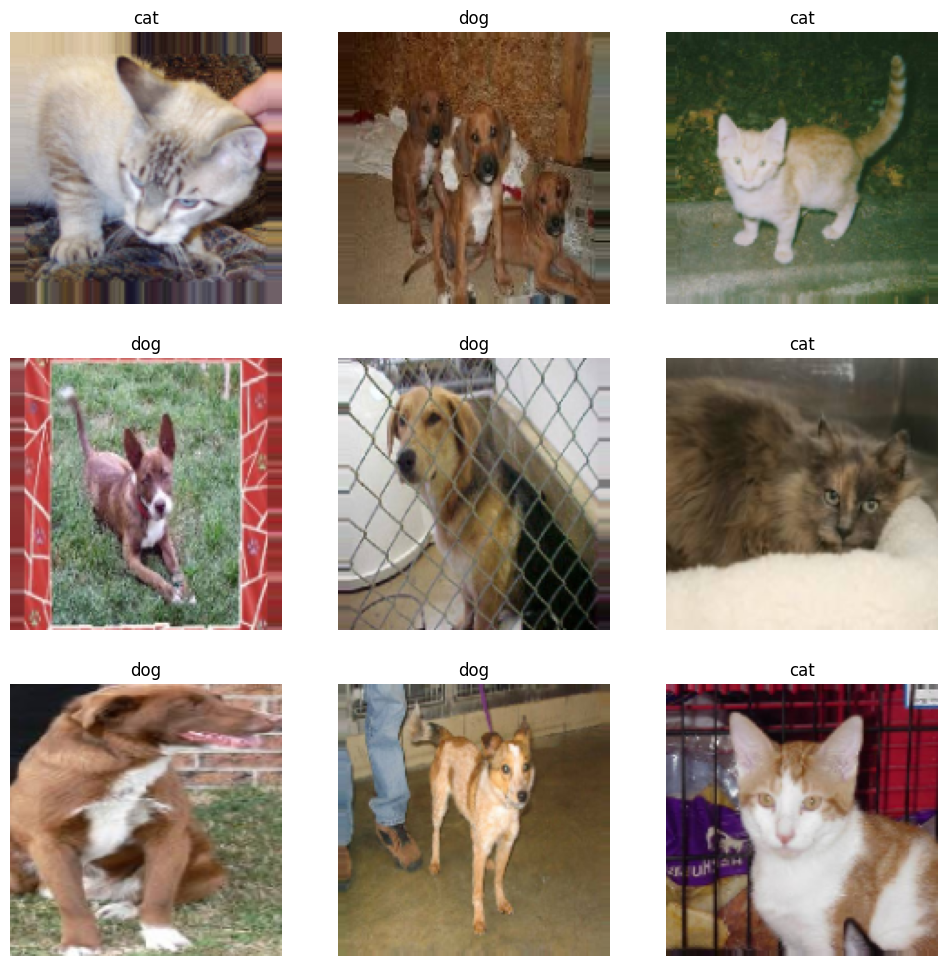

In [ ]:
def plot_sample_images(generator):
    """Muestra un lote de imágenes del generador."""
    # Nota: class_map debe estar definido previamente
    # class_map = {0: 'gatos', 1: 'perros'}
    img_batch, label_batch = next(generator)
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Keras devuelve lotes de tensores, los convertimos a enteros para el mapeo
        label_index = int(label_batch[i])
        plt.imshow(img_batch[i])
        plt.title(class_map.get(label_index, "Clase desconocida"))
        plt.axis("off")
    plt.show()

# --- Ejecución ---
print("Imágenes de entrenamiento de muestra:")
# Se asume que 'train_generator' y 'class_map' ya fueron creados en celdas anteriores
plot_sample_images(train_generator)

## 3. Construcción del Modelo CNN

Ahora definimos la arquitectura de nuestra red. Usaremos una pila de capas `Conv2D` y `MaxPooling2D`, seguida de capas `Dense` para la clasificación.

- Se utilizan múltiples capas convolucionales para que la red pueda aprender características cada vez más complejas (de bordes a texturas y luego a partes de objetos).
- Se añade una capa `Dropout` para regularizar el modelo y reducir el sobreajuste, desactivando aleatoriamente neuronas durante el entrenamiento.
- **Optimizador**: Usaremos `Adam`, un algoritmo de optimización eficiente que ajusta la tasa de aprendizaje y que generalmente funciona mejor que el SGD tradicional para este tipo de problemas.

In [ ]:
from tensorflow.keras.layers import Input # Make sure to import Input

model = Sequential([
    # Add an explicit Input layer to define the shape
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # 1ra Capa Convolucional (now without the input_shape argument)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 2da Capa Convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 3ra Capa Convolucional
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Aplanar y conectar a capas densas
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Ver un resumen de la arquitectura
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento del Modelo

Ahora entrenamos el modelo usando el método `fit()`. Le pasamos los generadores de entrenamiento y validación. El generador de validación nos permite monitorear el rendimiento del modelo en datos que no ha visto después de cada época, lo cual es crucial para detectar el sobreajuste.

In [ ]:
# (This code replaces the cell where you define train_datagen, test_datagen, etc.)

import tensorflow as tf

# Definir rutas y parámetros
train_dir = os.path.join(image_dir, "train")
validation_dir = os.path.join(image_dir, "validation")
test_dir = os.path.join(image_dir, "test")

IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

# Crear los datasets de alto rendimiento
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'
)

# Optimizar el rendimiento del pipeline de datos
# .cache() guarda los datos en memoria después de la primera época
# .prefetch() superpone el preprocesamiento de datos y la ejecución del modelo
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets creados y optimizados con tf.data API.")

Found 15000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 12494 files belonging to 2 classes.
Datasets creados y optimizados con tf.data API.


### Visualización de los Resultados del Entrenamiento
Graficar la precisión y la pérdida del modelo en los conjuntos de entrenamiento y validación es la mejor manera de entender cómo progresó el aprendizaje.

In [ ]:
# Add this cell to inspect your data pipeline
import numpy as np

# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    numpy_images = images.numpy()
    # Print the shape, data type, min, and max pixel values
    print("Batch shape:", numpy_images.shape)
    print("Data type:", numpy_images.dtype)
    print("Min pixel value:", np.min(numpy_images))
    print("Max pixel value:", np.max(numpy_images))

Batch shape: (32, 150, 150, 3)
Data type: float32
Min pixel value: 0.0
Max pixel value: 255.0


In [ ]:
import tensorflow as tf
print("GPU devices found:", tf.config.list_physical_devices('GPU'))

GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


⚠️ GPU ya inicializada, continuando...
📦 Descargando y extrayendo datasets desde Google Drive...
Descargando /content/train.zip...
El directorio train ya existe. Eliminando /content/train.zip.
Descargando /content/test.zip...
El directorio test ya existe. Eliminando /content/test.zip.
Descargando /content/validation.zip...
El directorio validation ya existe. Eliminando /content/validation.zip.
📁 Directorio de entrenamiento: /content/train
📁 Directorio de validación: /content/validation
📁 Directorio de prueba: /content/test
Found 15000 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Found 7500 files belonging to 2 classes.
Mapeo de clases encontrado: {0: 'cat', 1: 'dog'}
✅ Datasets listos y optimizados.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento_de_datos (Sequential)   │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,563,713 (36.48 MB)

 Trainable params: 9,563,713 (36.48 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Entrenando el modelo...
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 45ms/step - accuracy: 0.5479 - loss: 0.7112 - val_accuracy: 0.6288 - val_loss: 0.6590
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - accuracy: 0.6306 - loss: 0.6445 - val_accuracy: 0.6792 - val_loss: 0.6121

📊 Evaluando el modelo en el conjunto de prueba...
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6593 - loss: 0.6402
Precisión en prueba: 0.68
Pérdida en prueba: 0.60


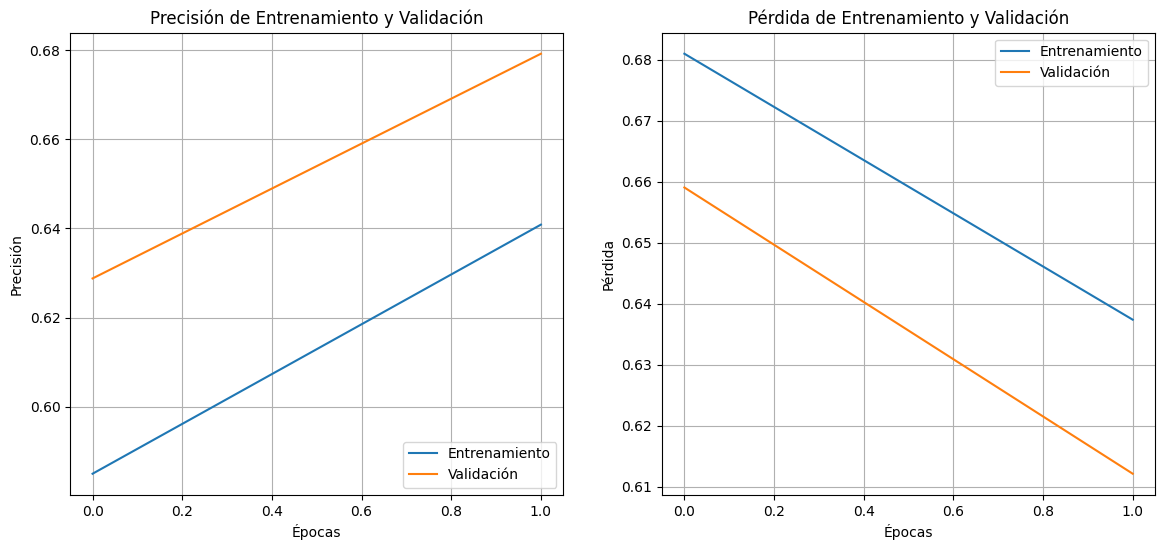


✅ Entrenamiento, evaluación y visualización completados correctamente.


In [ ]:
# ==============================================================================
# 🔥 DEMO RÁPIDA DE CNN EN TENSORFLOW (Optimizada para Colab y GPU)
# ==============================================================================

import os
import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile
import requests  # Agregado para descargas

# -------------------------------------------------------------------------
# 1. CONFIGURACIÓN Y GPU
# -------------------------------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detectada: {gpus}")
    except RuntimeError:
        print("⚠️ GPU ya inicializada, continuando...")
else:
    print("⚠️ No se detectó GPU, se usará CPU.")

# Habilitar precisión mixta (acelera cálculos en GPU)
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# -------------------------------------------------------------------------
# 2. CARGA DE DATOS DE EJEMPLO (desde Google Drive)
# -------------------------------------------------------------------------
print("📦 Descargando y extrayendo datasets desde Google Drive...")

contentFolder = '/content'  # Directorio base en Colab (ajusta si no estás en Colab)
image_dir = contentFolder  # Extraer directamente en /content para simplicidad

def download_file(url, save_path):
    """Descarga un archivo desde una URL a una ruta específica."""
    if not os.path.exists(save_path):
        print(f"Descargando {save_path}...")
        r = requests.get(url, stream=True)
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    else:
        print(f"{save_path} ya existe. Saltando descarga.")

def extract_zip(zip_path, extract_path):
    """Extrae un archivo zip a un directorio específico."""
    print(f"Extrayendo {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    os.remove(zip_path)  # Eliminar el archivo zip después de la extracción
    print("Extracción completa.")

# URLs de los datasets
urls = {
    "train.zip": "https://drive.usercontent.google.com/download?id=1t1qqX3yjvKaLSHP62Ovp6l2RIYYLprdi&export=download&confirm=t",
    "test.zip": "https://drive.usercontent.google.com/download?id=1VXEOECTyFXRkirsSBF-siXF_h3XBUWQ_&export=download&confirm=t",
    "validation.zip": "https://drive.usercontent.google.com/download?id=1PVJ_8OIEiDftfdyaUqVkoQhDXBrEPEhr&export=download&confirm=t"
}

# Descargar y extraer los archivos
for filename, url in urls.items():
    zip_path = os.path.join(contentFolder, filename)
    download_file(url, zip_path)
    # Solo extraer si el directorio correspondiente no existe
    dir_name = filename.split('.')[0]
    if not os.path.exists(os.path.join(image_dir, dir_name)):
        extract_zip(zip_path, image_dir)
    elif os.path.exists(zip_path):
        print(f"El directorio {dir_name} ya existe. Eliminando {zip_path}.")
        os.remove(zip_path)

# Definir rutas a los directorios de datos
train_dir = os.path.join(image_dir, "train")
validation_dir = os.path.join(image_dir, "validation")
test_dir = os.path.join(image_dir, "test")

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"No se encontró {train_dir}. Verifica la descarga/extracción o reinicia el runtime.")

print(f"📁 Directorio de entrenamiento: {train_dir}")
print(f"📁 Directorio de validación: {validation_dir}")
print(f"📁 Directorio de prueba: {test_dir}")

IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

# Crear los datasets (moderno y eficiente, evita warnings de PyDataset)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'  # Clasificación binaria (cat/dog)
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='binary'
)

# Mapeo de clases (usando class_names del dataset, antes de optimizaciones)
class_map = {i: name for i, name in enumerate(train_dataset.class_names)}
print(f"Mapeo de clases encontrado: {class_map}")

# OPTIMIZACIÓN: cache + prefetch para pipeline rápido
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Datasets listos y optimizados.\n")

# -------------------------------------------------------------------------
# 3. DEFINICIÓN DEL MODELO CNN
# -------------------------------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Rescaling, RandomFlip, RandomRotation, RandomZoom,
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout
)

# Aumento de datos como capas en el modelo (equivalente a shear/zoom/flip en ImageDataGenerator)
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.2),
    RandomZoom(0.2),
], name="aumento_de_datos")

model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,
    Rescaling(1./255),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid', dtype='float32')  # salida float32 para estabilidad
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------------------------------------------------
# 4. ENTRENAMIENTO RÁPIDO
# -------------------------------------------------------------------------
EPOCHS = 2  # Perfecto para demo rápida (<2 minutos)

print("\n🚀 Entrenando el modelo...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    verbose=1
)

# Restaurar política de precisión a float32 (buena práctica post-entrenamiento)
set_global_policy('float32')

# -------------------------------------------------------------------------
# 5. EVALUACIÓN EN EL CONJUNTO DE PRUEBA
# -------------------------------------------------------------------------
print("\n📊 Evaluando el modelo en el conjunto de prueba...")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Precisión en prueba: {test_acc:.2f}")
print(f"Pérdida en prueba: {test_loss:.2f}")

# -------------------------------------------------------------------------
# 6. VISUALIZAR RESULTADOS
# -------------------------------------------------------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True)

plt.show()

print("\n✅ Entrenamiento, evaluación y visualización completados correctamente.")

## 5. Evaluación del Modelo

Finalmente, evaluamos el rendimiento final de nuestro modelo en el conjunto de prueba, que el modelo nunca ha visto, ni para entrenamiento ni para validación. Esto nos da la estimación más honesta de cómo se comportará el modelo en el mundo real.

Evaluando el rendimiento del modelo en datos no vistos...
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6593 - loss: 0.6402

--- Resultados de la Evaluación ---
Pérdida en el conjunto de prueba: 0.6019
Precisión en el conjunto de prueba: 0.6821 (68.21%)
------------------------------------

Generando visualización de predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


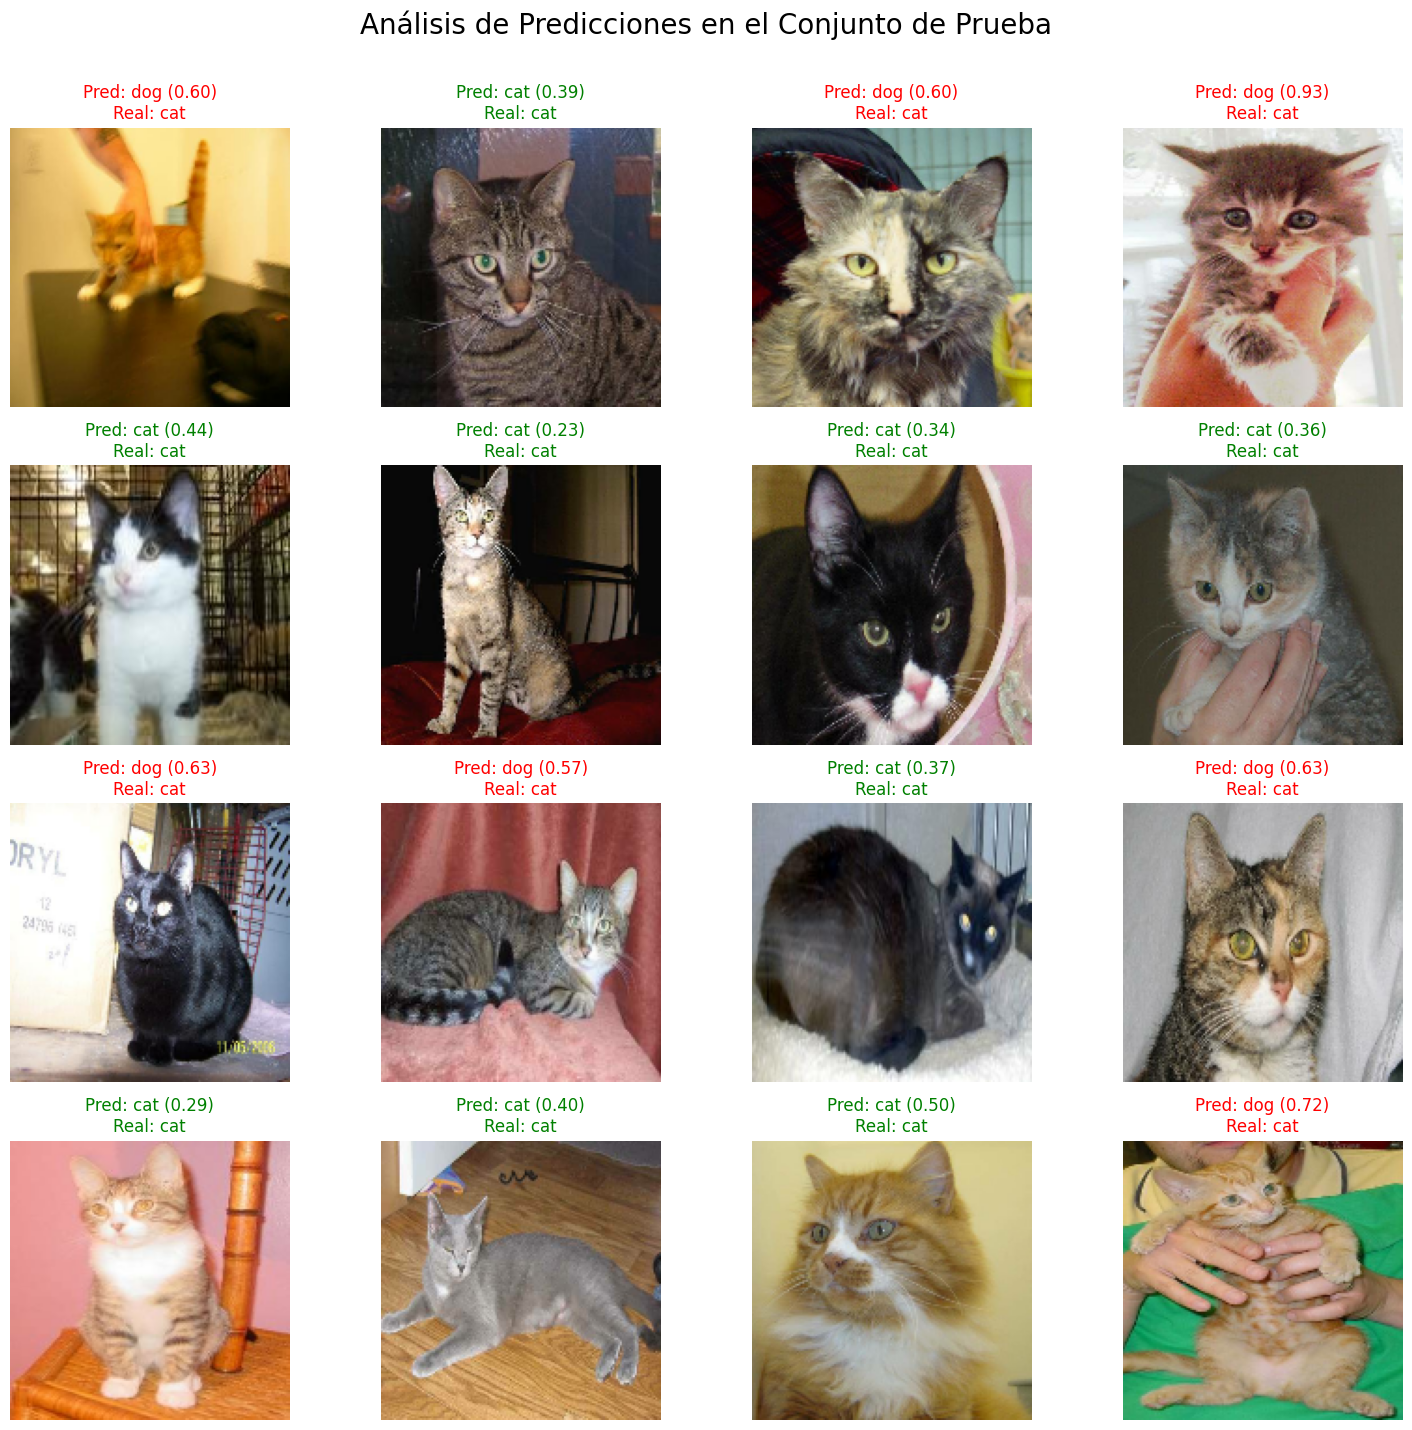

In [ ]:
# =========================================================================
# 📊 EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

print("Evaluando el rendimiento del modelo en datos no vistos...")

# model.evaluate() calcula la pérdida y las métricas en el dataset de prueba.
# Devuelve los valores calculados.
loss, accuracy = model.evaluate(test_dataset)

# Imprimimos los resultados con formato para una mejor lectura.
print("\n--- Resultados de la Evaluación ---")
print(f"Pérdida en el conjunto de prueba: {loss:.4f}")
print(f"Precisión en el conjunto de prueba: {accuracy:.4f} ({accuracy:.2%})")
print("------------------------------------")

# =========================================================================
# 🖼️ ANÁLISIS VISUAL DE PREDICCIONES
# =========================================================================
# Para tener una idea más clara de cómo se comporta el modelo,
# visualizaremos sus predicciones en un lote de imágenes de prueba.

print("\nGenerando visualización de predicciones...")

# Tomamos un lote de imágenes y etiquetas del dataset de prueba
images, labels = next(iter(test_dataset))

# Hacemos predicciones sobre ese lote de imágenes
predictions = model.predict(images)

# Mapeo de clases (asumiendo que ya tienes la variable 'class_map')
# Si no la tienes, puedes recrearla con: class_map = {0: 'cats', 1: 'dogs'}
# o el que corresponda a tu dataset.

plt.figure(figsize=(15, 15))
plt.suptitle("Análisis de Predicciones en el Conjunto de Prueba", fontsize=20)

for i in range(16):  # Mostramos las primeras 16 imágenes del lote
    if i >= len(images):
        break

    ax = plt.subplot(4, 4, i + 1)

    # Mostramos la imagen. Necesitamos convertirla a un array de numpy.
    plt.imshow(images[i].numpy().astype("uint8"))

    # La predicción es una probabilidad (sigmoid), la convertimos a una clase (0 o 1)
    predicted_prob = predictions[i][0]
    predicted_class = 1 if predicted_prob > 0.5 else 0
    true_class = int(labels[i])

    # Determinamos el color del título: verde si la predicción es correcta, rojo si no.
    title_color = 'green' if predicted_class == true_class else 'red'

    plt.title(
        f"Pred: {class_map[predicted_class]} ({predicted_prob:.2f})\n"
        f"Real: {class_map[true_class]}",
        color=title_color
    )
    plt.axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## 6. Análisis de Predicciones

Para tener una idea más cualitativa del rendimiento, podemos tomar un lote de imágenes del conjunto de prueba y visualizar las predicciones del modelo junto con la etiqueta real.

In [ ]:
# Obtener un lote de imágenes de prueba
test_images, true_labels = next(test_generator)

# Realizar predicciones
predictions = model.predict(test_images)

# Visualizar los resultados
plt.figure(figsize=(15, 15))
for i in range(16): # Mostramos 16 imágenes
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])

    # La predicción es una probabilidad, la convertimos a una clase
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    true_class = int(true_labels[i])

    # Poner el título en verde si es correcto, en rojo si es incorrecto
    title_color = 'green' if pred_class == true_class else 'red'

    plt.title(f"Pred: {class_map[pred_class]} ({pred_prob:.2f})\nReal: {class_map[true_class]}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()